<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/asgard_transport_dynamic_co2_tracing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dynamic CO₂ and flow tracing from Åsgard and Kristin to Kårstø

This notebook follows a **finite-duration composition and flow change** through a long
gas-export pipeline. Åsgard flow is held constant while Kristin flow rises temporarily
together with a CO₂ increase. NeqSim `master` calculates the offshore pressure needed
to retain 110 bara at Kårstø and compares first-order implicit transport, bounded TVD
Van Leer/SSP-RK2 transport, and an explicit physical-dispersion sensitivity.

A final executable `TwoFluidPipe` gate checks the component-resolved gas/oil inventories
and both phase-level and named-component conservation on a short synthetic wet-gas case.


## Why this is a separate notebook

The existing
[GasProcessingChain](../gasvaluechain/GasProcessingChain.ipynb) notebook already covers
the steady well-to-market chain and a long export-line pressure calculation. Its basis
uses 200 bara offshore, 110 bara at Kårstø, about 700 km, a 0.987 m screening diameter,
and about 20 GSm³/year.

Dynamic component transport is a different numerical problem and needs its own
conservation diagnostics, time history, and grid/time-step study. This focused notebook
therefore reuses that steady screening basis without making the value-chain notebook
larger or mixing validated and unvalidated transient solver paths.

Public context:

- [Gassco's Åsgard Transport overview](https://gassco.eu/en/rorledningsnettverk/2758/)
  describes the export route to Kårstø.
- [Gassco's operated-systems report](https://gassco.eu/wp-content/uploads/2025/01/Det-norske-gasstransportsystemet-2024.pdf)
  gives 707 km, 28/42 inch sections, and 71.7 MSm³/day capacity.
- [Sodir's Kristin field page](https://factpages.sodir.no/en/field/PageView/All/1854729)
  states that Kristin rich gas is transported through Åsgard Transport to Kårstø.
- [Gassco's Kårstø page](https://gassco.eu/en/prosessanlegg/karsto/) describes receipt
  of rich gas from Åsgard Transport.

The 700 km / 0.987 m model below is an effective screening representation inherited
from `GasProcessingChain`, not an as-built hydraulic model.

## Learning goals and model boundary

After running the notebook, you can:

1. mix two gas sources conservatively by component molar flow;
2. prescribe temporary CO₂ and field-flow changes;
3. calculate the inlet pressure required to retain a fixed 110 bara receipt pressure;
4. propagate the event with first-order and bounded high-resolution component transport;
5. separate numerical pulse spreading from an explicit physical-dispersion sensitivity;
6. audit every component balance, CFL value, Peclet diagnostic, bound, and EOS synchronization error;
7. run a component-resolved two-phase gas/oil conservation gate with `TwoFluidPipe`.

The geometry and source data remain synthetic screening inputs. The long line is one
effective isothermal gas pipe, not a calibrated Åsgard Transport digital twin. The
physical-dispersion coefficient is illustrative and must not be treated as field calibration.


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_COMMIT = "df68ad7295b9dae6a324d941761a303d9f301fb5"
local_root = os.environ.get("NEQSIM_PROJECT_ROOT")
PROJECT_ROOT = Path(local_root or "/content/neqsim-main").resolve()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"

if importlib.util.find_spec("jpype") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "JPype1>=1.5"],
        check=True,
    )

if not (PROJECT_ROOT / "pom.xml").exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--filter=blob:none",
            "--branch",
            NEQSIM_SOURCE_REF,
            "https://github.com/equinor/neqsim.git",
            str(PROJECT_ROOT),
        ],
        check=True,
    )
    subprocess.run(
        ["git", "checkout", "--detach", NEQSIM_SOURCE_COMMIT],
        cwd=PROJECT_ROOT,
        check=True,
    )
    subprocess.run(
        ["./mvnw", "-q", "-DskipTests", "package"],
        cwd=PROJECT_ROOT,
        check=True,
        timeout=1800,
    )

if local_root:
    checked_out_commit = os.environ.get("NEQSIM_SOURCE_COMMIT", NEQSIM_SOURCE_COMMIT)
else:
    checked_out_commit = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT, text=True
    ).strip()
assert checked_out_commit == NEQSIM_SOURCE_COMMIT

import jpype

jpype.addClassPath(str(PROJECT_ROOT / "target" / "classes"))
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False)
JClass = ns.JClass

PipeFlowSystem = JClass(
    "neqsim.fluidmechanics.flowsystem.onephaseflowsystem."
    "pipeflowsystem.PipeFlowSystem"
)
class_location = str(
    PipeFlowSystem.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert "target/classes" in class_location.replace("\\", "/")
print("Expected NeqSim master commit:", NEQSIM_SOURCE_COMMIT)
print("PipeFlowSystem loaded from:", class_location)


Expected NeqSim master commit: df68ad7295b9dae6a324d941761a303d9f301fb5
PipeFlowSystem loaded from: file:/workspace/scratch/75c92a56ec97/neqsim-java/target/classes/


In [2]:
import math
import time

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
LoopedPipeNetwork = JClass("neqsim.process.equipment.network.LoopedPipeNetwork")
PipeData = JClass("neqsim.fluidmechanics.geometrydefinitions.pipe.PipeData")
GeometryDefinitionInterface = JClass(
    "neqsim.fluidmechanics.geometrydefinitions.GeometryDefinitionInterface"
)
SystemInterface = JClass("neqsim.thermo.system.SystemInterface")
SpeciesAdvectionScheme = JClass(
    "neqsim.fluidmechanics.flowsolver.SpeciesAdvectionScheme"
)
ConstantAxialDispersion = JClass(
    "neqsim.fluidmechanics.flowsolver.ConstantAxialDispersion"
)
Stream = JClass("neqsim.process.equipment.stream.Stream")
TwoFluidPipe = JClass("neqsim.process.equipment.pipeline.TwoFluidPipe")
TwoFluidComponentPhase = JClass(
    "neqsim.process.equipment.pipeline."
    "TwoFluidComponentConservationReport$Phase"
)
TwoFluidMassPhase = JClass(
    "neqsim.process.equipment.pipeline.TwoFluidMassBalanceReport$Phase"
)
JavaUUID = JClass("java.util.UUID")

DoubleArray = jpype.JArray(jpype.JDouble)
GeometryArray = jpype.JArray(GeometryDefinitionInterface)
SystemArray = jpype.JArray(SystemInterface)

COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#666666",
}


## Scenario basis

The pressure basis follows the supplied value-chain example: about **200 bara offshore**
and **110 bara at Kårstø** for a 700 km effective line. Baseline total flow is
457.5 kg/s (about 20 GSm³/year for this synthetic lean gas).

During the 12-hour event, Åsgard remains at baseline flow while Kristin rises by 25%.
This raises total export by 6.25%. Kristin CO₂ simultaneously rises from 1.2 to
4.0 mol%. The higher-pressure event boundary is not guessed: a NeqSim steady hydraulic
root solve finds the inlet pressure that returns the Kårstø boundary to 110 bara.


In [3]:
TEMPERATURE_K = 288.15
INLET_PRESSURE_BARA = 200.0
TARGET_KARSTO_PRESSURE_BARA = 110.0
PIPE_LENGTH_M = 700_000.0
PIPE_DIAMETER_M = 0.987
ROUGHNESS_M = 50.0e-6
TOTAL_FLOW_KG_S = 457.5
ASGARD_FLOW_KG_S = 0.75 * TOTAL_FLOW_KG_S
KRISTIN_FLOW_KG_S = 0.25 * TOTAL_FLOW_KG_S
KRISTIN_EVENT_FLOW_MULTIPLIER = 1.25
KRISTIN_EVENT_FLOW_KG_S = KRISTIN_FLOW_KG_S * KRISTIN_EVENT_FLOW_MULTIPLIER
EVENT_TOTAL_FLOW_KG_S = ASGARD_FLOW_KG_S + KRISTIN_EVENT_FLOW_KG_S

EVENT_START_H = 6.0
EVENT_DURATION_H = 12.0
EVENT_END_H = EVENT_START_H + EVENT_DURATION_H
HORIZON_H = 96.0
MONITORING_LEVEL_MOL_PERCENT = 1.0
PHYSICAL_DISPERSION_M2_S = 250.0

COMPONENTS = ["methane", "ethane", "propane", "CO2", "nitrogen"]
ASGARD_BASE = {
    "methane": 0.940,
    "ethane": 0.035,
    "propane": 0.006,
    "CO2": 0.008,
    "nitrogen": 0.011,
}
KRISTIN_BASE = {
    "methane": 0.925,
    "ethane": 0.040,
    "propane": 0.008,
    "CO2": 0.012,
    "nitrogen": 0.015,
}
KRISTIN_EVENT = dict(KRISTIN_BASE)
KRISTIN_EVENT["CO2"] = 0.040
KRISTIN_EVENT["methane"] -= KRISTIN_EVENT["CO2"] - KRISTIN_BASE["CO2"]

basis = pd.DataFrame(
    {
        "parameter": [
            "Effective length",
            "Effective inner diameter",
            "Roughness",
            "Baseline inlet / Kårstø pressure",
            "Baseline total mass flow",
            "Kristin flow uplift",
            "Total event flow uplift",
            "Kristin CO₂ event",
        ],
        "value": [
            f"{PIPE_LENGTH_M / 1000:.0f} km",
            f"{PIPE_DIAMETER_M:.3f} m",
            f"{ROUGHNESS_M * 1e6:.0f} µm",
            f"{INLET_PRESSURE_BARA:.0f} / {TARGET_KARSTO_PRESSURE_BARA:.0f} bara",
            f"{TOTAL_FLOW_KG_S:.1f} kg/s",
            f"{KRISTIN_FLOW_KG_S:.1f} → {KRISTIN_EVENT_FLOW_KG_S:.1f} kg/s",
            f"{TOTAL_FLOW_KG_S:.1f} → {EVENT_TOTAL_FLOW_KG_S:.1f} kg/s",
            f"{KRISTIN_BASE['CO2'] * 100:.1f} → {KRISTIN_EVENT['CO2'] * 100:.1f} mol%",
        ],
        "provenance": [
            "GasProcessingChain screening basis",
            "GasProcessingChain screening basis",
            "GasProcessingChain screening basis",
            "User-supplied screening basis",
            "Synthetic; selected to match pressure basis",
            "Synthetic sensitivity",
            "Derived from source flows",
            "Synthetic sensitivity",
        ],
    }
)
display(basis)


,parameter,value,provenance
0,Effective length,700 km,GasProcessingChain screening basis
1,Effective inner diameter,0.987 m,GasProcessingChain screening basis
2,Roughness,50 µm,GasProcessingChain screening basis
3,Baseline inlet / Kårstø pressure,200 / 110 bara,User-supplied screening basis
4,Baseline total mass flow,457.5 kg/s,Synthetic; selected to match pressure basis
5,Kristin flow uplift,114.4 → 143.0 kg/s,Synthetic sensitivity
6,Total event flow uplift,457.5 → 486.1 kg/s,Derived from source flows
7,Kristin CO₂ event,1.2 → 4.0 mol%,Synthetic sensitivity


## Conservative source mixing

`LoopedPipeNetwork` mixes incoming streams by component molar flow. For source $s$,

$$
\dot n_{i,s} =
\frac{\dot m_s}{\overline M_s} x_{i,s},
\qquad
x_{i,\mathrm{mix}} =
\frac{\sum_s \dot n_{i,s}}
{\sum_i \sum_s \dot n_{i,s}} .
$$

This is a steady junction calculation for each boundary state. It does **not** add
dynamic inventory to the two source branches. The downstream long-pipe transient is
then solved explicitly.

In [4]:
def make_fluid(composition, mass_flow_kg_s, pressure_bara=INLET_PRESSURE_BARA):
    values = np.array([composition[name] for name in COMPONENTS])
    assert np.isclose(values.sum(), 1.0, atol=1.0e-12)
    assert np.all(values >= 0.0)

    fluid = SystemSrkEos(TEMPERATURE_K, pressure_bara)
    for name, fraction in zip(COMPONENTS, values):
        fluid.addComponent(name, float(fraction))
    fluid.createDatabase(True)
    fluid.setMixingRule("classic")
    fluid.init(0)
    fluid.init(3)
    fluid.initPhysicalProperties()
    fluid.setTotalFlowRate(mass_flow_kg_s, "kg/sec")
    return fluid


def mole_fraction_dict(fluid):
    phase = fluid.getPhase(0)
    return {name: float(phase.getComponent(name).getx()) for name in COMPONENTS}


def mix_sources(
    kristin_composition,
    kristin_flow_kg_s=KRISTIN_FLOW_KG_S,
    inlet_pressure_bara=INLET_PRESSURE_BARA,
):
    total_flow_kg_s = ASGARD_FLOW_KG_S + kristin_flow_kg_s
    asgard = make_fluid(ASGARD_BASE, ASGARD_FLOW_KG_S, inlet_pressure_bara)
    kristin = make_fluid(
        kristin_composition, kristin_flow_kg_s, inlet_pressure_bara
    )

    network = LoopedPipeNetwork("Synthetic Åsgard Transport sources")
    network.addSourceNode(
        "Asgard source", inlet_pressure_bara, ASGARD_FLOW_KG_S * 3600.0
    )
    network.addSourceNode(
        "Kristin source", inlet_pressure_bara, kristin_flow_kg_s * 3600.0
    )
    network.addJunctionNode("Mixing node")
    network.addSinkNode("Karsto", total_flow_kg_s * 3600.0)

    asgard_edge = network.addPipe(
        "Asgard source", "Mixing node", "Asgard branch", 1.0, 1.0
    )
    kristin_edge = network.addPipe(
        "Kristin source", "Mixing node", "Kristin branch", 1.0, 1.0
    )
    export_edge = network.addPipe(
        "Mixing node", "Karsto", "Export branch", 1.0, 1.0
    )
    asgard_edge.setFlowRate(ASGARD_FLOW_KG_S)
    kristin_edge.setFlowRate(kristin_flow_kg_s)
    export_edge.setFlowRate(total_flow_kg_s)

    network.setNodeFluid("Asgard source", asgard)
    network.setNodeFluid("Kristin source", kristin)
    report = network.updateCompositionalMixingWithReport()
    assert report.isConverged(), report.getMessage()

    mixed = network.getNodeFluid("Mixing node").clone()
    mixed.setPressure(inlet_pressure_bara, "bara")
    mixed.setTotalFlowRate(total_flow_kg_s, "kg/sec")
    mixed.init(3)
    mixed.initPhysicalProperties()
    return mixed, report, asgard, kristin


baseline_mixed, baseline_mix_report, asgard_gas, kristin_gas = mix_sources(
    KRISTIN_BASE
)
event_mixed_at_200, event_mix_report, _, kristin_event_gas = mix_sources(
    KRISTIN_EVENT, KRISTIN_EVENT_FLOW_KG_S
)

mixing_rows = []
for label, fluid in [
    ("Åsgard source", asgard_gas),
    ("Kristin baseline", kristin_gas),
    ("Kristin event", kristin_event_gas),
    ("Mixed baseline", baseline_mixed),
    ("Mixed event with flow uplift", event_mixed_at_200),
]:
    row = {"state": label}
    row.update(
        {
            f"{name} [mol%]": 100.0 * value
            for name, value in mole_fraction_dict(fluid).items()
        }
    )
    mixing_rows.append(row)

mixing_table = pd.DataFrame(mixing_rows).set_index("state")
display(mixing_table.round(4))

for report in [baseline_mix_report, event_mix_report]:
    assert report.getMaxComponentMassBalanceResidualKgS() < 1.0e-10
    assert report.getMaxComponentBalanceResidualMolS() < 1.0e-8

standard_flow_gsm3_y = baseline_mixed.getFlowRate("MSm3/day") * 365.0 / 1000.0
print(f"Equivalent baseline standard flow: {standard_flow_gsm3_y:.2f} GSm³/year")


Equivalent baseline standard flow: 19.92 GSm³/year


,methane [mol%],ethane [mol%],propane [mol%],CO2 [mol%],nitrogen [mol%]
state,,,,,
Åsgard source,94.0000,3.5000,0.6000,0.8000,1.1000
Kristin baseline,92.5000,4.0000,0.8000,1.2000,1.5000
Kristin event,89.7000,4.0000,0.8000,4.0000,1.5000
Mixed baseline,93.6297,3.6234,0.6494,0.8988,1.1988
Mixed event with flow uplift,92.7889,3.6408,0.6563,1.7013,1.2127


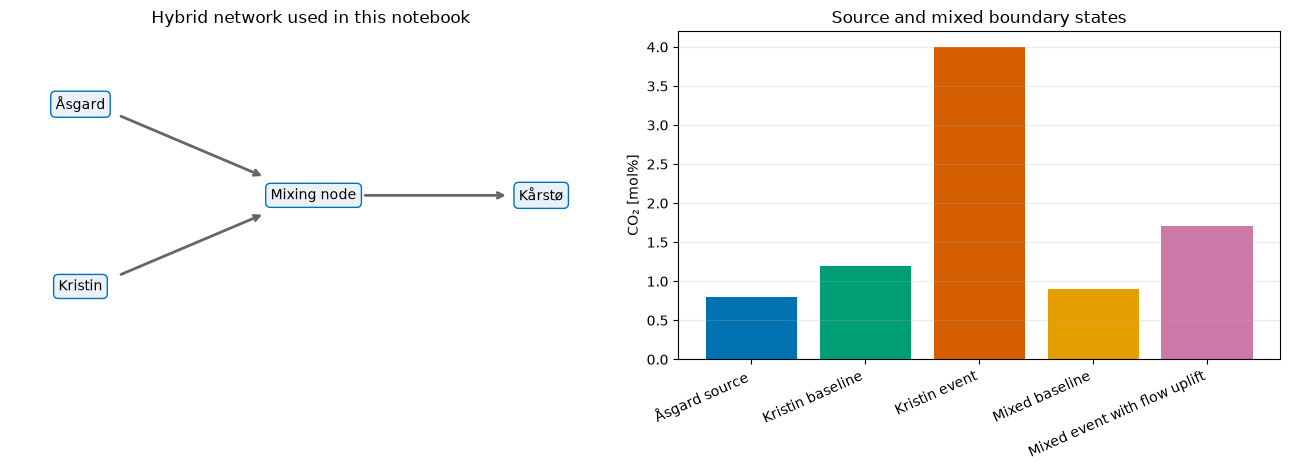

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))

positions = {
    "Åsgard": (0.05, 0.75),
    "Kristin": (0.05, 0.25),
    "Mixing node": (0.48, 0.50),
    "Kårstø": (0.90, 0.50),
}
for name, (x_value, y_value) in positions.items():
    axes[0].text(
        x_value,
        y_value,
        name,
        ha="center",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "#EAF2F8",
            "edgecolor": COLORS["blue"],
        },
        zorder=3,
    )
for start, end in [
    ((0.12, 0.72), (0.39, 0.55)),
    ((0.12, 0.28), (0.39, 0.45)),
    ((0.57, 0.50), (0.84, 0.50)),
]:
    axes[0].annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={
            "arrowstyle": "->",
            "color": COLORS["grey"],
            "lw": 2,
        },
        zorder=1,
    )
axes[0].set_title("Hybrid network used in this notebook")
axes[0].set_xlim(-0.08, 1.03)
axes[0].set_ylim(0.05, 0.95)
axes[0].axis("off")

states = [
    "Åsgard source",
    "Kristin baseline",
    "Kristin event",
    "Mixed baseline",
    "Mixed event with flow uplift",
]
co2_values = mixing_table.loc[states, "CO2 [mol%]"]
axes[1].bar(
    np.arange(len(states)),
    co2_values,
    color=[
        COLORS["blue"],
        COLORS["green"],
        COLORS["red"],
        COLORS["orange"],
        COLORS["purple"],
    ],
)
axes[1].set_xticks(np.arange(len(states)), states, rotation=24, ha="right")
axes[1].set_ylabel("CO₂ [mol%]")
axes[1].set_title("Source and mixed boundary states")
axes[1].grid(axis="y", alpha=0.25)
figure.tight_layout()
plt.show()

## Conservative finite-volume transport and physical dispersion

The compatibility method advances each independent component with fully implicit
first-order upwind transport. For constant coefficients its modified-equation reference is

$$
D_{num,implicit}=\frac{1}{2}u\,\Delta x\,(1+CFL).
$$

The opt-in `TVD_VAN_LEER_SSP_RK2` method uses limited MUSCL face reconstruction and
two-stage strong-stability-preserving Runge–Kutta integration. It conserves the same
component inventories but automatically substeps until the local mass CFL is at most 0.45.

NeqSim `master` also supports an independent conservative physical axial-dispersion flux,

$$
\frac{\partial (M Y_i)}{\partial t}
+ \frac{\partial (\dot m Y_i)}{\partial x}
= \frac{\partial}{\partial x}
\left(\rho A D_{ax}\frac{\partial Y_i}{\partial x}\right).
$$

The third run uses constant $D_{ax}=250\ \mathrm{m^2/s}$ with prescribed inlet
composition and zero-gradient outlet diffusive flux. This value is an illustrative API
sensitivity adopted from the NeqSim documentation example, not a measurement or
calibration for Åsgard Transport.


In [6]:
def build_pipe(number_of_nodes, inlet_system):
    pipe = PipeFlowSystem()
    pipe.setInletThermoSystem(inlet_system.clone())
    pipe.setNumberOfLegs(1)
    pipe.setNumberOfNodesInLeg(number_of_nodes)

    inlet_geometry = PipeData()
    outlet_geometry = PipeData()
    for geometry in [inlet_geometry, outlet_geometry]:
        geometry.setDiameter(PIPE_DIAMETER_M)
        geometry.setInnerSurfaceRoughness(ROUGHNESS_M)

    pipe.setEquipmentGeometry(GeometryArray([inlet_geometry, outlet_geometry]))
    pipe.setLegHeights(DoubleArray([0.0, 0.0]))
    pipe.setLegPositions(DoubleArray([0.0, PIPE_LENGTH_M]))
    pipe.setLegOuterTemperatures(DoubleArray([TEMPERATURE_K, TEMPERATURE_K]))
    pipe.setLegWallHeatTransferCoefficients(DoubleArray([0.0, 0.0]))
    pipe.setLegOuterHeatTransferCoefficients(DoubleArray([0.0, 0.0]))

    pipe.createSystem()
    pipe.init()
    pipe.solveSteadyState(1)
    flow_report = pipe.getConvergenceReport()
    assert flow_report.isConverged(), flow_report.getMessage()
    return pipe


def steady_outlet_pressure(inlet_pressure_bara, number_of_nodes=24):
    mixed, _, _, _ = mix_sources(
        KRISTIN_EVENT,
        KRISTIN_EVENT_FLOW_KG_S,
        inlet_pressure_bara,
    )
    pipe = build_pipe(number_of_nodes, mixed)
    outlet = float(
        pipe.getNode(pipe.getTotalNumberOfNodes() - 1)
        .getBulkSystem()
        .getPressure("bara")
    )
    return outlet


def solve_required_event_inlet_pressure(number_of_nodes=24):
    lower = INLET_PRESSURE_BARA
    upper = INLET_PRESSURE_BARA + 40.0
    lower_outlet = steady_outlet_pressure(lower, number_of_nodes)
    upper_outlet = steady_outlet_pressure(upper, number_of_nodes)
    assert lower_outlet < TARGET_KARSTO_PRESSURE_BARA
    assert upper_outlet > TARGET_KARSTO_PRESSURE_BARA

    for _ in range(12):
        midpoint = 0.5 * (lower + upper)
        midpoint_outlet = steady_outlet_pressure(midpoint, number_of_nodes)
        if midpoint_outlet < TARGET_KARSTO_PRESSURE_BARA:
            lower = midpoint
        else:
            upper = midpoint
    required = 0.5 * (lower + upper)
    return required, steady_outlet_pressure(required, number_of_nodes), lower_outlet


baseline_pressure_pipe = build_pipe(24, baseline_mixed)
baseline_outlet_pressure_bara = float(
    baseline_pressure_pipe.getNode(
        baseline_pressure_pipe.getTotalNumberOfNodes() - 1
    )
    .getBulkSystem()
    .getPressure("bara")
)
(
    EVENT_INLET_PRESSURE_BARA,
    event_outlet_pressure_bara,
    event_outlet_at_200_bara,
) = solve_required_event_inlet_pressure(24)
event_mixed, event_mix_report, _, _ = mix_sources(
    KRISTIN_EVENT,
    KRISTIN_EVENT_FLOW_KG_S,
    EVENT_INLET_PRESSURE_BARA,
)

pressure_basis = pd.DataFrame(
    {
        "case": ["Baseline", "Event at 200 bara", "Event pressure solved"],
        "total flow [kg/s]": [
            TOTAL_FLOW_KG_S,
            EVENT_TOTAL_FLOW_KG_S,
            EVENT_TOTAL_FLOW_KG_S,
        ],
        "inlet pressure [bara]": [
            INLET_PRESSURE_BARA,
            INLET_PRESSURE_BARA,
            EVENT_INLET_PRESSURE_BARA,
        ],
        "Kårstø pressure [bara]": [
            baseline_outlet_pressure_bara,
            event_outlet_at_200_bara,
            event_outlet_pressure_bara,
        ],
    }
)
display(pressure_basis.round(3))
assert abs(baseline_outlet_pressure_bara - TARGET_KARSTO_PRESSURE_BARA) < 2.0
assert event_outlet_at_200_bara < baseline_outlet_pressure_bara
assert EVENT_INLET_PRESSURE_BARA > INLET_PRESSURE_BARA
assert abs(event_outlet_pressure_bara - TARGET_KARSTO_PRESSURE_BARA) < 0.1


def mass_to_mole_profile(mass_profile, component_names):
    molar_masses = np.array(
        [
            baseline_mixed.getPhase(0).getComponent(name).getMolarMass()
            for name in component_names
        ]
    )
    molar_density = mass_profile / molar_masses[:, None]
    return molar_density / molar_density.sum(axis=0, keepdims=True)


def run_pulse(
    number_of_nodes,
    time_step_seconds,
    species_scheme,
    axial_dispersion_m2_s=0.0,
):
    pipe = build_pipe(number_of_nodes, baseline_mixed)
    pipe.setSpeciesAdvectionScheme(species_scheme)
    pipe.setAxialDispersionModel(
        ConstantAxialDispersion(float(axial_dispersion_m2_s))
    )
    pipe.setConservativeSpeciesTransport(True)
    pipe.setFailOnNonConvergence(True)
    pipe.setStoreSpeciesConservationHistory(False)

    number_of_steps = int(round(HORIZON_H * 3600.0 / time_step_seconds))
    accepted_times_h = (np.arange(number_of_steps) + 1) * time_step_seconds / 3600.0
    baseline_co2 = mole_fraction_dict(baseline_mixed)["CO2"]
    event_co2 = mole_fraction_dict(event_mixed)["CO2"]

    inlet_co2 = []
    inlet_flow_kg_s = []
    inlet_pressure_bara = []
    outlet_co2 = []
    mole_profiles = []
    pressure_profiles_bara = []
    initial_inventories = []
    final_inventories = []
    inlet_masses = []
    outlet_masses = []
    step_diagnostics = []
    component_names = None
    co2_index = None

    started = time.perf_counter()
    for step in range(number_of_steps):
        midpoint_h = (step + 0.5) * time_step_seconds / 3600.0
        event_active = EVENT_START_H <= midpoint_h < EVENT_END_H
        state = event_mixed if event_active else baseline_mixed
        inlet_co2.append(event_co2 if event_active else baseline_co2)
        inlet_flow_kg_s.append(
            EVENT_TOTAL_FLOW_KG_S if event_active else TOTAL_FLOW_KG_S
        )
        inlet_pressure_bara.append(
            EVENT_INLET_PRESSURE_BARA if event_active else INLET_PRESSURE_BARA
        )

        time_series = pipe.getTimeSeries()
        time_series.setTimes(DoubleArray([0.0, time_step_seconds]))
        time_series.setInletThermoSystems(SystemArray([state.clone()]))
        time_series.setNumberOfTimeStepsInInterval(1)
        time_series.setOutletMolarFlowRate(None)
        time_series.setOutletPressure(DoubleArray([TARGET_KARSTO_PRESSURE_BARA]))
        pipe.solveTransient(1)

        report = pipe.getSpeciesConservationReport()
        assert report.isConverged(), report.getMessage()
        if component_names is None:
            component_names = [str(name) for name in report.getComponentNames()]
            co2_index = component_names.index("CO2")
        mass_profile = np.array(report.getMassFractionProfile(), dtype=float)
        mole_profile = mass_to_mole_profile(mass_profile, component_names)
        transport = report.getTransportDiagnostics()

        mole_profiles.append(mole_profile)
        outlet_co2.append(mole_profile[co2_index, -1])
        initial_inventories.append(np.array(report.getInitialInventoryKg(), dtype=float))
        final_inventories.append(np.array(report.getFinalInventoryKg(), dtype=float))
        inlet_masses.append(np.array(report.getInletBoundaryMassKg(), dtype=float))
        outlet_masses.append(np.array(report.getOutletBoundaryMassKg(), dtype=float))
        pressure_profiles_bara.append(
            [
                pipe.getNode(index).getBulkSystem().getPressure("bara")
                for index in range(pipe.getTotalNumberOfNodes())
            ]
        )
        step_diagnostics.append(
            {
                "converged": bool(report.isConverged()),
                "max_relative_inventory_residual": report.getMaximumRelativeInventoryResidual(),
                "mass_fraction_sum_error": report.getMaximumMassFractionSumError(),
                "thermodynamic_sync_error": report.getMaximumThermodynamicMassFractionError(),
                "minimum_mass_fraction": report.getMinimumMassFraction(),
                "maximum_mass_fraction": report.getMaximumMassFraction(),
                "coupling_iterations": report.getCouplingIterations(),
                "scheme": str(transport.getScheme().name()),
                "maximum_full_step_cfl": transport.getMaximumCellCourantNumber(),
                "transport_substeps": transport.getSubsteps(),
                "first_order_D_num_reference_m2_s": (
                    transport.getMaximumFirstOrderImplicitNumericalDispersionM2PerSecond()
                ),
                "physical_dispersion_included": bool(
                    transport.isPhysicalDispersionIncluded()
                ),
                "physical_dispersion_model": str(
                    transport.getPhysicalDispersionModelName()
                ),
                "physical_D_min_m2_s": (
                    transport.getMinimumPhysicalAxialDispersionM2PerSecond()
                ),
                "physical_D_max_m2_s": (
                    transport.getMaximumPhysicalAxialDispersionM2PerSecond()
                ),
                "maximum_physical_dispersion_number": (
                    transport.getMaximumCellPhysicalDispersionNumber()
                ),
                "dispersion_inlet_boundary": str(
                    transport.getInletDispersionBoundaryCondition().name()
                ),
                "dispersion_outlet_boundary": str(
                    transport.getOutletDispersionBoundaryCondition().name()
                ),
            }
        )

    runtime_seconds = time.perf_counter() - started
    mole_profiles = np.array(mole_profiles)
    pressure_profiles_bara = np.array(pressure_profiles_bara)
    physical_cell_count = mole_profiles.shape[2]
    distance_km = np.linspace(0.0, PIPE_LENGTH_M / 1000.0, physical_cell_count)
    node_distance_km = np.array(
        [
            pipe.getNode(index).getDistanceToCenterOfNode() / 1000.0
            for index in range(pipe.getTotalNumberOfNodes())
        ]
    )

    return {
        "pipe": pipe,
        "component_names": component_names,
        "co2_index": co2_index,
        "time_h": accepted_times_h,
        "inlet_co2": np.array(inlet_co2),
        "inlet_flow_kg_s": np.array(inlet_flow_kg_s),
        "inlet_pressure_bara": np.array(inlet_pressure_bara),
        "outlet_co2": np.array(outlet_co2),
        "mole_profiles": mole_profiles,
        "distance_km": distance_km,
        "initial_inventory_kg": np.array(initial_inventories),
        "final_inventory_kg": np.array(final_inventories),
        "inlet_mass_kg": np.array(inlet_masses),
        "outlet_mass_kg": np.array(outlet_masses),
        "diagnostics": pd.DataFrame(step_diagnostics),
        "pressure_profiles_bara": pressure_profiles_bara,
        "pressure_bara": pressure_profiles_bara[-1],
        "node_distance_km": node_distance_km,
        "runtime_seconds": runtime_seconds,
        "nodes": number_of_nodes,
        "time_step_seconds": time_step_seconds,
        "scheme": str(species_scheme.name()),
        "axial_dispersion_m2_s": float(axial_dispersion_m2_s),
    }


,case,total flow [kg/s],inlet pressure [bara],Kårstø pressure [bara]
0,Baseline,457.500,200.000,110.338
1,Event at 200 bara,486.094,200.000,97.892
2,Event pressure solved,486.094,207.026,110.005


In [7]:
implicit_result = run_pulse(
    number_of_nodes=24,
    time_step_seconds=1800.0,
    species_scheme=SpeciesAdvectionScheme.FIRST_ORDER_IMPLICIT,
)
base_result = run_pulse(
    number_of_nodes=24,
    time_step_seconds=1800.0,
    species_scheme=SpeciesAdvectionScheme.TVD_VAN_LEER_SSP_RK2,
)
dispersion_result = run_pulse(
    number_of_nodes=24,
    time_step_seconds=1800.0,
    species_scheme=SpeciesAdvectionScheme.TVD_VAN_LEER_SSP_RK2,
    axial_dispersion_m2_s=PHYSICAL_DISPERSION_M2_S,
)
base_pipe = base_result["pipe"]


def summary_row(label, result):
    diagnostic = result["diagnostics"]
    return {
        "case": label,
        "scheme": result["scheme"],
        "D_ax [m²/s]": result["axial_dispersion_m2_s"],
        "nodes": result["nodes"],
        "time step [min]": result["time_step_seconds"] / 60.0,
        "runtime [s]": result["runtime_seconds"],
        "maximum full-step CFL": diagnostic["maximum_full_step_cfl"].max(),
        "maximum transport substeps": diagnostic["transport_substeps"].max(),
        "maximum physical-dispersion number": diagnostic[
            "maximum_physical_dispersion_number"
        ].max(),
        "first-order D_num reference [m²/s]": diagnostic[
            "first_order_D_num_reference_m2_s"
        ].max(),
    }


run_summary = pd.DataFrame(
    [
        summary_row("First-order / no physical dispersion", implicit_result),
        summary_row("TVD / no physical dispersion", base_result),
        summary_row("TVD / illustrative physical dispersion", dispersion_result),
    ]
)
display(run_summary.round(4))

assert base_result["diagnostics"]["scheme"].eq(
    "TVD_VAN_LEER_SSP_RK2"
).all()
assert not base_result["diagnostics"]["physical_dispersion_included"].any()
assert dispersion_result["diagnostics"]["physical_dispersion_included"].all()
assert np.allclose(
    dispersion_result["diagnostics"]["physical_D_max_m2_s"],
    PHYSICAL_DISPERSION_M2_S,
)
assert np.max(
    np.abs(
        base_result["pressure_profiles_bara"][:, -1]
        - TARGET_KARSTO_PRESSURE_BARA
    )
) < 0.1


,case,scheme,D_ax [m²/s],nodes,time step [min],runtime [s],maximum full-step CFL,maximum transport substeps,maximum physical-dispersion number,first-order D_num reference [m²/s]
0,First-order / no physical dispersion,FIRST_ORDER_IMPLICIT,0.0,24,30.0,21.3445,0.3123,1,0.0000,96827.6388
1,TVD / no physical dispersion,TVD_VAN_LEER_SSP_RK2,0.0,24,30.0,22.5655,0.3123,1,0.0000,96827.6388
2,TVD / illustrative physical dispersion,TVD_VAN_LEER_SSP_RK2,250.0,24,30.0,21.8512,0.3123,1,0.0016,96827.6388


In [8]:
baseline_co2 = mole_fraction_dict(baseline_mixed)["CO2"]
event_co2 = mole_fraction_dict(event_mixed)["CO2"]
event_amplitude = event_co2 - baseline_co2
time_h = base_result["time_h"]
outlet_co2 = base_result["outlet_co2"]

arrival_indices = np.flatnonzero(
    outlet_co2 >= baseline_co2 + 0.10 * event_amplitude
)
assert arrival_indices.size > 0
arrival_time_h = time_h[arrival_indices[0]]
peak_index = int(np.argmax(outlet_co2))
peak_time_h = time_h[peak_index]
peak_co2 = outlet_co2[peak_index]
implicit_peak_co2 = implicit_result["outlet_co2"].max()
dispersion_peak_co2 = dispersion_result["outlet_co2"].max()

outlet_excess = np.maximum(outlet_co2 - baseline_co2, 0.0)
centroid_time_h = np.trapezoid(time_h * outlet_excess, time_h) / np.trapezoid(
    outlet_excess, time_h
)
inlet_centroid_h = 0.5 * (EVENT_START_H + EVENT_END_H)
centroid_delay_h = centroid_time_h - inlet_centroid_h

monitoring_mask = 100.0 * outlet_co2 >= MONITORING_LEVEL_MOL_PERCENT
time_above_monitoring_h = (
    monitoring_mask.sum() * base_result["time_step_seconds"] / 3600.0
)
initial_linepack_kg = base_result["initial_inventory_kg"][0].sum()
linepack_residence_h = initial_linepack_kg / TOTAL_FLOW_KG_S / 3600.0
final_recovery_fraction = (outlet_co2[-1] - baseline_co2) / event_amplitude

implicit_transmission = (
    implicit_peak_co2 - baseline_co2
) / event_amplitude
tvd_transmission = (peak_co2 - baseline_co2) / event_amplitude
dispersion_transmission = (
    dispersion_peak_co2 - baseline_co2
) / event_amplitude

kpis = pd.DataFrame(
    {
        "KPI": [
            "Mixed baseline CO₂",
            "Mixed event CO₂ (composition + flow uplift)",
            "Total flow during event",
            "Required event inlet pressure",
            "Kårstø pressure boundary",
            "10% arrival at Kårstø (TVD)",
            "Peak time at Kårstø (TVD)",
            "Peak CO₂ at Kårstø (TVD)",
            "First-order peak amplitude transmitted",
            "TVD peak amplitude transmitted",
            "TVD + illustrative dispersion peak transmitted",
            "Outlet excess centroid delay (TVD)",
            "Initial linepack / baseline flow",
            "Time above illustrative 1.0 mol%",
            "End-of-run residual pulse",
        ],
        "value": [
            f"{100.0 * baseline_co2:.4f} mol%",
            f"{100.0 * event_co2:.4f} mol%",
            f"{EVENT_TOTAL_FLOW_KG_S:.2f} kg/s (+{100.0 * (EVENT_TOTAL_FLOW_KG_S / TOTAL_FLOW_KG_S - 1.0):.2f}%)",
            f"{EVENT_INLET_PRESSURE_BARA:.2f} bara",
            f"{TARGET_KARSTO_PRESSURE_BARA:.2f} bara",
            f"{arrival_time_h:.1f} h from simulation start",
            f"{peak_time_h:.1f} h from simulation start",
            f"{100.0 * peak_co2:.4f} mol%",
            f"{100.0 * implicit_transmission:.1f}%",
            f"{100.0 * tvd_transmission:.1f}%",
            f"{100.0 * dispersion_transmission:.1f}%",
            f"{centroid_delay_h:.1f} h",
            f"{linepack_residence_h:.1f} h",
            f"{time_above_monitoring_h:.1f} h",
            f"{100.0 * final_recovery_fraction:.2f}% of inlet amplitude",
        ],
    }
)
display(kpis)
assert tvd_transmission > implicit_transmission
assert EVENT_INLET_PRESSURE_BARA > INLET_PRESSURE_BARA


,KPI,value
0,Mixed baseline CO₂,0.8988 mol%
1,Mixed event CO₂ (composition + flow uplift),1.7013 mol%
2,Total flow during event,486.09 kg/s (+6.25%)
3,Required event inlet pressure,207.03 bara
4,Kårstø pressure boundary,110.00 bara
5,10% arrival at Kårstø (TVD),50.5 h from simulation start
6,Peak time at Kårstø (TVD),61.5 h from simulation start
7,Peak CO₂ at Kårstø (TVD),1.5465 mol%
8,First-order peak amplitude transmitted,42.2%
9,TVD peak amplitude transmitted,80.7%


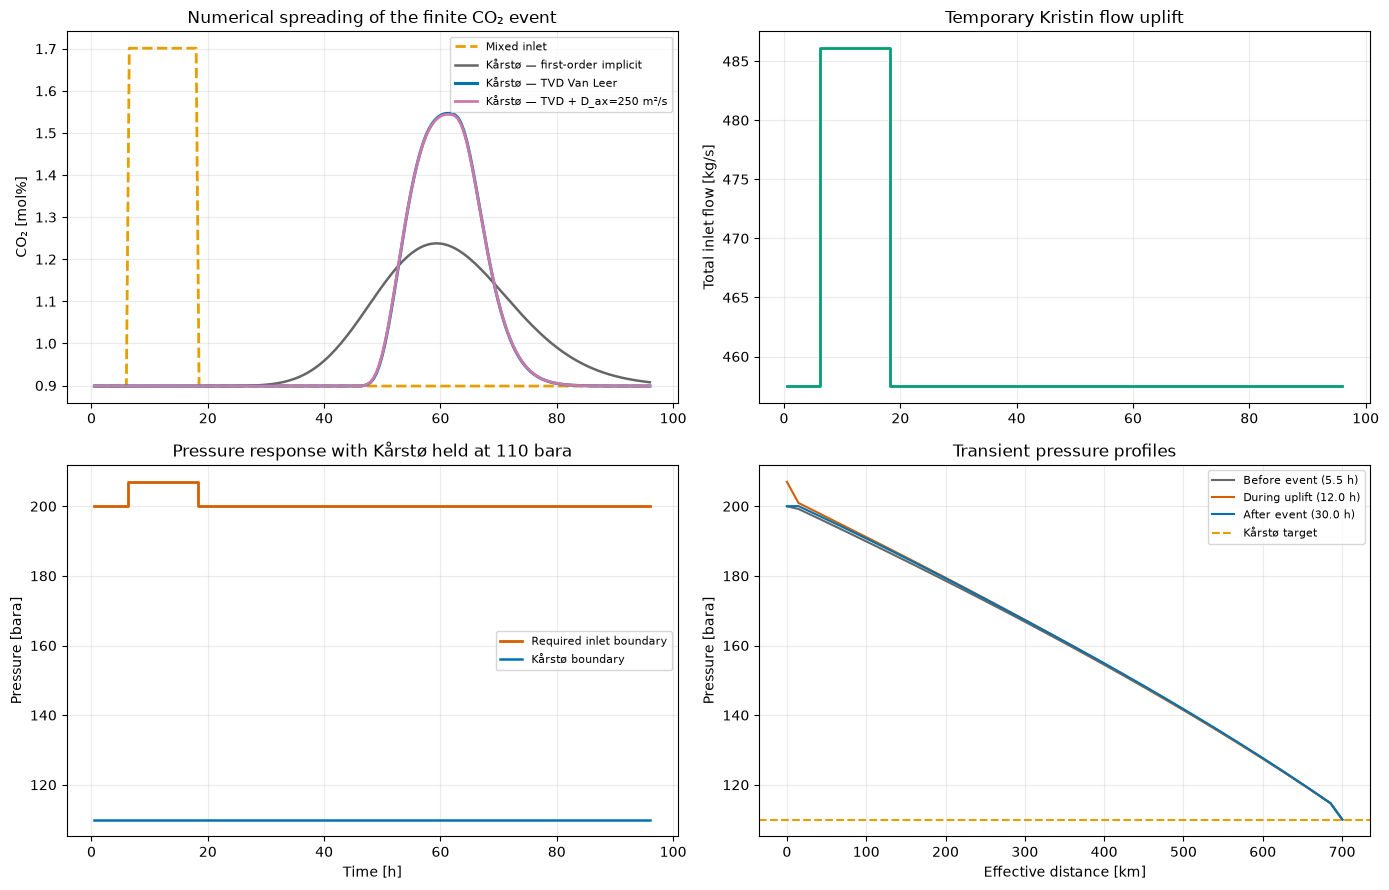

In [9]:
figure, axes = plt.subplots(2, 2, figsize=(14.0, 9.0))
axes[0, 0].plot(
    time_h,
    100.0 * base_result["inlet_co2"],
    color=COLORS["orange"],
    linestyle="--",
    linewidth=2,
    label="Mixed inlet",
)
axes[0, 0].plot(
    implicit_result["time_h"],
    100.0 * implicit_result["outlet_co2"],
    color=COLORS["grey"],
    linewidth=1.8,
    label="Kårstø — first-order implicit",
)
axes[0, 0].plot(
    time_h,
    100.0 * outlet_co2,
    color=COLORS["blue"],
    linewidth=2.2,
    label="Kårstø — TVD Van Leer",
)
axes[0, 0].plot(
    dispersion_result["time_h"],
    100.0 * dispersion_result["outlet_co2"],
    color=COLORS["purple"],
    linewidth=2.0,
    label=f"Kårstø — TVD + D_ax={PHYSICAL_DISPERSION_M2_S:.0f} m²/s",
)
axes[0, 0].set_ylabel("CO₂ [mol%]")
axes[0, 0].set_title("Numerical spreading of the finite CO₂ event")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.25)

axes[0, 1].step(
    time_h,
    base_result["inlet_flow_kg_s"],
    where="mid",
    color=COLORS["green"],
    linewidth=2,
)
axes[0, 1].set_ylabel("Total inlet flow [kg/s]")
axes[0, 1].set_title("Temporary Kristin flow uplift")
axes[0, 1].grid(alpha=0.25)

axes[1, 0].step(
    time_h,
    base_result["inlet_pressure_bara"],
    where="mid",
    color=COLORS["red"],
    linewidth=2,
    label="Required inlet boundary",
)
axes[1, 0].plot(
    time_h,
    base_result["pressure_profiles_bara"][:, -1],
    color=COLORS["blue"],
    linewidth=1.8,
    label="Kårstø boundary",
)
axes[1, 0].set_xlabel("Time [h]")
axes[1, 0].set_ylabel("Pressure [bara]")
axes[1, 0].set_title("Pressure response with Kårstø held at 110 bara")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.25)

for requested_time, label, color in [
    (5.5, "Before event", COLORS["grey"]),
    (12.0, "During uplift", COLORS["red"]),
    (30.0, "After event", COLORS["blue"]),
]:
    index = int(np.argmin(np.abs(time_h - requested_time)))
    axes[1, 1].plot(
        base_result["node_distance_km"],
        base_result["pressure_profiles_bara"][index],
        label=f"{label} ({time_h[index]:.1f} h)",
        color=color,
    )
axes[1, 1].axhline(
    TARGET_KARSTO_PRESSURE_BARA,
    color=COLORS["orange"],
    linestyle="--",
    label="Kårstø target",
)
axes[1, 1].set_xlabel("Effective distance [km]")
axes[1, 1].set_ylabel("Pressure [bara]")
axes[1, 1].set_title("Transient pressure profiles")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.25)

figure.tight_layout()
plt.show()


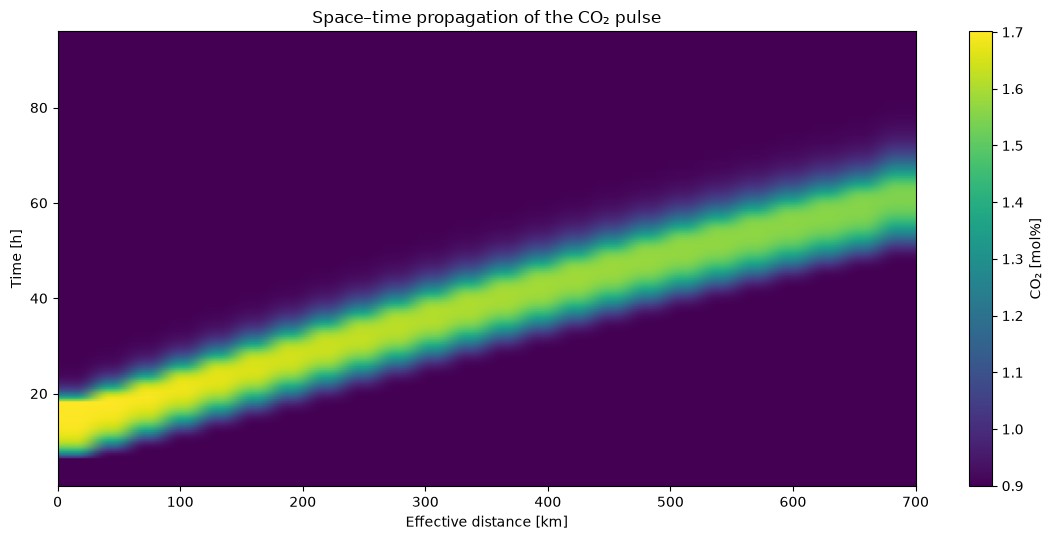

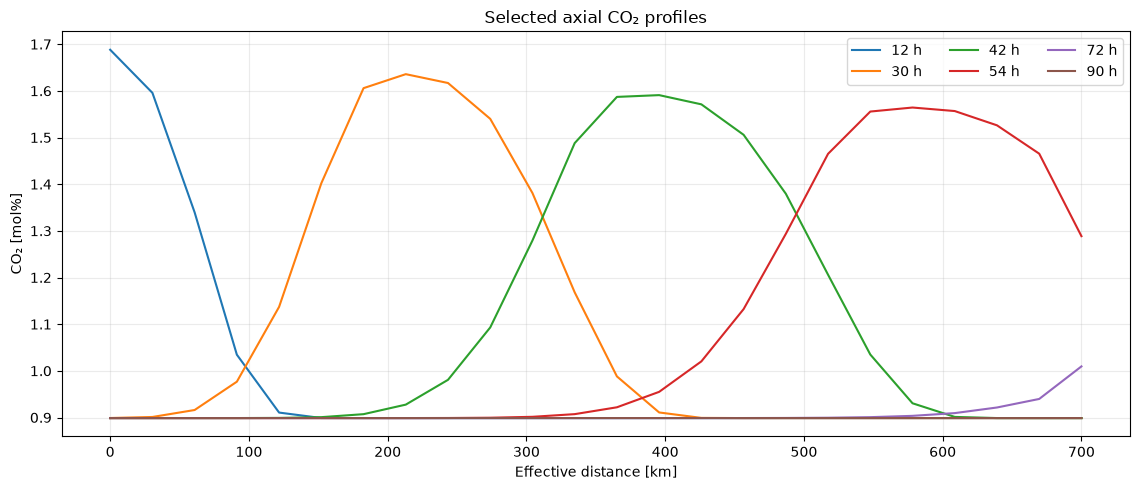

In [10]:
co2_profile = (
    100.0
    * base_result["mole_profiles"][:, base_result["co2_index"], :]
)
figure, axis = plt.subplots(figsize=(11.5, 5.5))
image = axis.imshow(
    co2_profile,
    origin="lower",
    aspect="auto",
    extent=[
        base_result["distance_km"][0],
        base_result["distance_km"][-1],
        time_h[0],
        time_h[-1],
    ],
    cmap="viridis",
)
colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("CO₂ [mol%]")
axis.set_xlabel("Effective distance [km]")
axis.set_ylabel("Time [h]")
axis.set_title("Space–time propagation of the CO₂ pulse")
figure.tight_layout()
plt.show()

figure, axis = plt.subplots(figsize=(11.5, 5.0))
for requested_time in [12.0, 30.0, 42.0, 54.0, 72.0, 90.0]:
    index = int(np.argmin(np.abs(time_h - requested_time)))
    axis.plot(
        base_result["distance_km"],
        co2_profile[index],
        label=f"{time_h[index]:.0f} h",
    )
axis.set_xlabel("Effective distance [km]")
axis.set_ylabel("CO₂ [mol%]")
axis.set_title("Selected axial CO₂ profiles")
axis.legend(ncol=3)
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()

## Conservation, pressure, and numerical-resolution gates

The event is accepted only if every component closes, all fractions remain bounded,
the EOS state stays synchronized, the outlet pressure boundary remains at 110 bara,
and the transport diagnostic confirms the selected method and its CFL/substep behavior.


In [11]:
diagnostics = base_result["diagnostics"]
initial_inventory = base_result["initial_inventory_kg"][0]
final_inventory = base_result["final_inventory_kg"][-1]
cumulative_inlet = base_result["inlet_mass_kg"].sum(axis=0)
cumulative_outlet = base_result["outlet_mass_kg"].sum(axis=0)
cumulative_residual = (
    final_inventory - initial_inventory - cumulative_inlet + cumulative_outlet
)
cumulative_scale = np.maximum.reduce(
    [np.abs(initial_inventory), np.abs(cumulative_inlet), np.ones_like(initial_inventory)]
)
cumulative_relative_residual = np.abs(cumulative_residual) / cumulative_scale
maximum_outlet_pressure_error = np.max(
    np.abs(
        base_result["pressure_profiles_bara"][:, -1]
        - TARGET_KARSTO_PRESSURE_BARA
    )
)

component_balance = pd.DataFrame(
    {
        "component": base_result["component_names"],
        "initial inventory [kg]": initial_inventory,
        "cumulative inlet [kg]": cumulative_inlet,
        "cumulative outlet [kg]": cumulative_outlet,
        "final inventory [kg]": final_inventory,
        "cumulative residual [kg]": cumulative_residual,
        "relative residual": cumulative_relative_residual,
    }
)
display(component_balance.round(8))

gate_table = pd.DataFrame(
    {
        "gate": [
            "All accepted steps converged",
            "Selected scheme",
            "Maximum step inventory residual",
            "Maximum cumulative component residual",
            "Maximum mass-fraction sum error",
            "Maximum thermo synchronization error",
            "Minimum / maximum mass fraction",
            "Maximum full-step CFL",
            "Maximum automatic transport substeps",
            "Physical-dispersion sensitivity enabled",
            "Physical-dispersion boundary conditions",
            "Maximum Kårstø pressure error",
            "Required pressure rises during flow uplift",
            "Pulse recovered by horizon",
        ],
        "result": [
            str(bool(diagnostics["converged"].all())),
            diagnostics["scheme"].iloc[0],
            f"{diagnostics['max_relative_inventory_residual'].max():.3e}",
            f"{cumulative_relative_residual.max():.3e}",
            f"{diagnostics['mass_fraction_sum_error'].max():.3e}",
            f"{diagnostics['thermodynamic_sync_error'].max():.3e}",
            f"{diagnostics['minimum_mass_fraction'].min():.6f} / {diagnostics['maximum_mass_fraction'].max():.6f}",
            f"{diagnostics['maximum_full_step_cfl'].max():.4f}",
            str(int(diagnostics["transport_substeps"].max())),
            str(bool(dispersion_result["diagnostics"]["physical_dispersion_included"].all())),
            (
                dispersion_result["diagnostics"]["dispersion_inlet_boundary"].iloc[0]
                + " / "
                + dispersion_result["diagnostics"]["dispersion_outlet_boundary"].iloc[0]
            ),
            f"{maximum_outlet_pressure_error:.3e} bar",
            f"{INLET_PRESSURE_BARA:.2f} → {EVENT_INLET_PRESSURE_BARA:.2f} bara",
            f"{100.0 * final_recovery_fraction:.2f}%",
        ],
        "limit": [
            "True",
            "TVD_VAN_LEER_SSP_RK2",
            "≤ 1e-8",
            "≤ 2e-7",
            "≤ 1e-12",
            "≤ 1e-10",
            "≥ 0 / ≤ 1",
            "reported; substep CFL ≤ 0.45",
            "finite positive integer",
            "True at 250 m²/s",
            "DIRICHLET_INLET / ZERO_GRADIENT_OUTLET",
            "≤ 0.1 bar",
            "event > baseline",
            "≤ 5% inlet amplitude",
        ],
    }
)
display(gate_table)

assert diagnostics["converged"].all()
assert diagnostics["scheme"].eq("TVD_VAN_LEER_SSP_RK2").all()
assert diagnostics["max_relative_inventory_residual"].max() <= 1.0e-8
assert cumulative_relative_residual.max() <= 2.0e-7
assert diagnostics["mass_fraction_sum_error"].max() <= 1.0e-12
assert diagnostics["thermodynamic_sync_error"].max() <= 1.0e-10
assert diagnostics["minimum_mass_fraction"].min() >= 0.0
assert diagnostics["maximum_mass_fraction"].max() <= 1.0
assert dispersion_result["diagnostics"]["physical_dispersion_included"].all()
assert dispersion_result["diagnostics"]["dispersion_inlet_boundary"].eq(
    "DIRICHLET_INLET"
).all()
assert dispersion_result["diagnostics"]["dispersion_outlet_boundary"].eq(
    "ZERO_GRADIENT_OUTLET"
).all()
assert maximum_outlet_pressure_error <= 0.1
assert EVENT_INLET_PRESSURE_BARA > INLET_PRESSURE_BARA
assert final_recovery_fraction <= 0.05
print("PASS — conservation, bounds, EOS, CFL, pressure, and recovery gates")


PASS — conservation, bounds, EOS, CFL, pressure, and recovery gates


,component,initial inventory [kg],cumulative inlet [kg],cumulative outlet [kg],final inventory [kg],cumulative residual [kg],relative residual
0,methane,7.067923e+07,1.379215e+08,1.380046e+08,7.059609e+07,0.002665,0.0
1,ethane,5.126822e+06,1.002209e+07,1.002812e+07,5.120791e+06,0.000193,0.0
2,propane,1.347411e+06,2.635966e+06,2.637551e+06,1.345826e+06,0.000051,0.0
3,CO2,1.861174e+06,4.053671e+06,4.055860e+06,1.858985e+06,0.000071,0.0
4,nitrogen,1.580126e+06,3.091586e+06,3.093445e+06,1.578267e+06,0.003309,0.0


,gate,result,limit
0,All accepted steps converged,True,True
1,Selected scheme,TVD_VAN_LEER_SSP_RK2,TVD_VAN_LEER_SSP_RK2
2,Maximum step inventory residual,7.209e-10,≤ 1e-8
3,Maximum cumulative component residual,1.070e-09,≤ 2e-7
4,Maximum mass-fraction sum error,0.000e+00,≤ 1e-12
5,Maximum thermo synchronization error,6.661e-16,≤ 1e-10
6,Minimum / maximum mass fraction,0.016673 / 0.876971,≥ 0 / ≤ 1
7,Maximum full-step CFL,0.3123,reported; substep CFL ≤ 0.45
8,Maximum automatic transport substeps,1,finite positive integer
9,Physical-dispersion sensitivity enabled,True,True at 250 m²/s


## Joint grid/time-step refinement

The TVD result is repeated on coarse and fine grid/time combinations without retuning
the limiter. All cases include the same temporary Kristin flow and CO₂ uplift. The
common-time outlet difference should decrease under joint refinement; the comparison
checks convergence but does not calibrate physical dispersion.


Coarse → base common-time MAD: 4.205446e-04
Base → fine common-time MAD:   1.700735e-04
PASS — joint grid/time-step refinement reduces outlet difference


,case,nodes,time step [min],runtime [s],peak time [h],peak CO2 [mol%],maximum full-step CFL
0,Coarse,12,60,6.30749,60.00000,1.34044,0.30985
1,Base,24,30,22.56548,61.50000,1.54650,0.31226
2,Fine,36,20,50.00776,61.66667,1.64371,0.31464


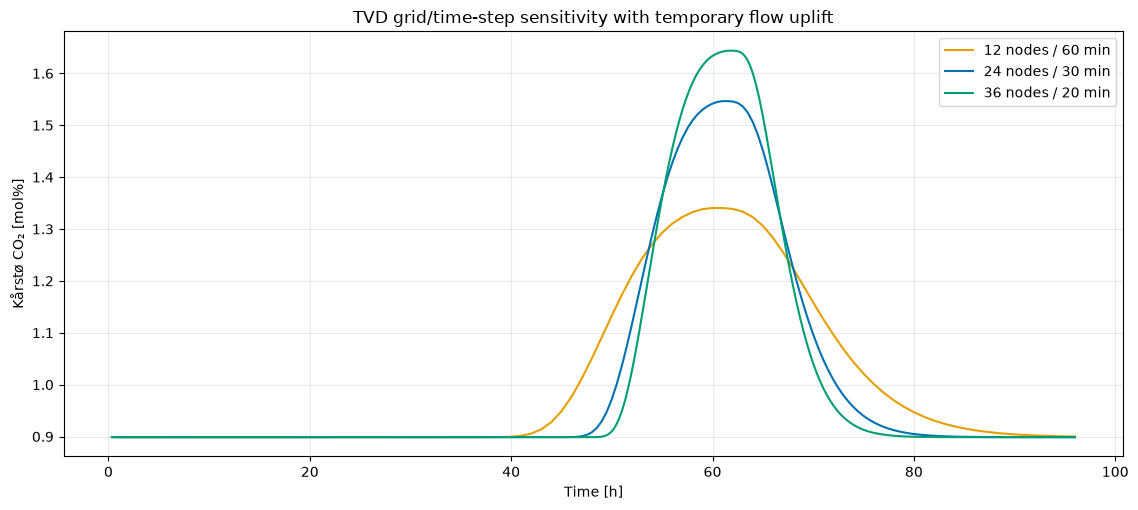

In [12]:
coarse_result = run_pulse(
    12, 3600.0, SpeciesAdvectionScheme.TVD_VAN_LEER_SSP_RK2
)
fine_result = run_pulse(
    36, 1200.0, SpeciesAdvectionScheme.TVD_VAN_LEER_SSP_RK2
)

common_time_h = np.arange(1.0, HORIZON_H + 0.1, 1.0)


def interpolate_outlet(result):
    return np.interp(common_time_h, result["time_h"], result["outlet_co2"])


coarse_common = interpolate_outlet(coarse_result)
base_common = interpolate_outlet(base_result)
fine_common = interpolate_outlet(fine_result)
coarse_to_base = np.mean(np.abs(coarse_common - base_common))
base_to_fine = np.mean(np.abs(base_common - fine_common))

refinement_table = pd.DataFrame(
    {
        "case": ["Coarse", "Base", "Fine"],
        "nodes": [12, 24, 36],
        "time step [min]": [60, 30, 20],
        "runtime [s]": [
            coarse_result["runtime_seconds"],
            base_result["runtime_seconds"],
            fine_result["runtime_seconds"],
        ],
        "peak time [h]": [
            coarse_result["time_h"][np.argmax(coarse_result["outlet_co2"])],
            peak_time_h,
            fine_result["time_h"][np.argmax(fine_result["outlet_co2"])],
        ],
        "peak CO2 [mol%]": [
            100.0 * coarse_result["outlet_co2"].max(),
            100.0 * base_result["outlet_co2"].max(),
            100.0 * fine_result["outlet_co2"].max(),
        ],
        "maximum full-step CFL": [
            coarse_result["diagnostics"]["maximum_full_step_cfl"].max(),
            base_result["diagnostics"]["maximum_full_step_cfl"].max(),
            fine_result["diagnostics"]["maximum_full_step_cfl"].max(),
        ],
    }
)
display(refinement_table.round(5))
print(f"Coarse → base common-time MAD: {coarse_to_base:.6e}")
print(f"Base → fine common-time MAD:   {base_to_fine:.6e}")
assert base_to_fine < coarse_to_base
print("PASS — joint grid/time-step refinement reduces outlet difference")

figure, axis = plt.subplots(figsize=(11.5, 5.2))
for result, label, color in [
    (coarse_result, "12 nodes / 60 min", COLORS["orange"]),
    (base_result, "24 nodes / 30 min", COLORS["blue"]),
    (fine_result, "36 nodes / 20 min", COLORS["green"]),
]:
    axis.plot(
        result["time_h"],
        100.0 * result["outlet_co2"],
        label=label,
        color=color,
    )
axis.set_xlabel("Time [h]")
axis.set_ylabel("Kårstø CO₂ [mol%]")
axis.set_title("TVD grid/time-step sensitivity with temporary flow uplift")
axis.legend()
axis.grid(alpha=0.25)
figure.tight_layout()
plt.show()


## What the result means

- Higher Kristin flow increases both Kristin's weight in the mixed CO₂ composition and
  total export flow.
- With Kårstø fixed at 110 bara, the steady hydraulic root solve requires a higher
  offshore pressure during the event. The transient then uses that calculated pressure
  schedule and verifies the 110 bara boundary at every accepted step.
- TVD transports more of the finite inlet amplitude to the outlet than fully implicit
  first-order upwind on the same grid and timestep; that difference is numerical.
- The third curve adds a separately declared physical term. Its change relative to
  pure TVD is a coefficient sensitivity only. Operational or published tracer data are
  still required before selecting a field value.


## Assessment of current NeqSim composition-tracking models

| Capability | Status used here | Consequence / follow-up |
|---|---|---|
| Conservative `PipeFlowSystem` species transport | First-order compatibility default plus bounded TVD Van Leer/SSP-RK2, merged in [NeqSim PR #2835](https://github.com/equinor/neqsim/pull/2835) | Direct numerical-resolution comparison runs from NeqSim `master` |
| Numerical-resolution diagnostics | Per accepted step: scheme, local/effective CFL, substeps, and first-order $D_{num}$ reference | Numerical spreading remains explicit |
| Physical axial dispersion | Opt-in conservative flux merged in [NeqSim PR #2838](https://github.com/equinor/neqsim/pull/2838) | A 250 m²/s illustrative sensitivity is shown; calibration remains external |
| `LoopedPipeNetwork` | Conservative steady junction mixing, no time-dependent edge inventory | Full network transient remains [NeqSim #2825](https://github.com/equinor/neqsim/issues/2825) |
| `OnePhasePipeLine` wrapper | Conservative public wrapper is available on `master` | Low-level `PipeFlowSystem` is retained here for direct cell diagnostics |
| `TwoFluidPipe` | Opt-in component inventories, accepted phase-flux coupling, interphase transfer, latent heat, and immutable reports merged in [NeqSim PR #2837](https://github.com/equinor/neqsim/pull/2837) | The executable wet-gas gate below checks the new public path |


## Final two-fluid component-transport gate

The long export-line calculation above remains deliberately one phase. The final test
therefore uses a separate, short synthetic wet-gas line at 15 °C and 50 bara. A
multiphase flash must contain both gas and hydrocarbon liquid before the `TwoFluidPipe`
run is accepted.

For each component $i$, the immutable report checks

$$
r_i=m_{i,f}-m_{i,0}-m_{i,in}+m_{i,out},
$$

while the hydrodynamic report independently checks gas, oil, water, liquid, and total
phase mass. CO₂ must have positive gas and oil inventories, phase transfer must be
equal and opposite, fractions must remain bounded, component sums must stay synchronized
with hydrodynamic phase mass, and a repeated fresh run must return the same result.

This is a regression/integration gate for the public `master` API, not a validation of
the 700 km screening case as multiphase or a claim of equivalence to a commercial
multiphase simulator.


In [13]:
TWOFLUID_COMPOSITION = {
    "methane": 0.69,
    "ethane": 0.10,
    "propane": 0.05,
    "n-pentane": 0.10,
    "n-heptane": 0.05,
    "CO2": 0.01,
}


def run_twofluid_component_gate():
    fluid = SystemSrkEos(288.15, 50.0)
    for name, fraction in TWOFLUID_COMPOSITION.items():
        fluid.addComponent(name, fraction)
    fluid.createDatabase(True)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    fluid.init(0)
    fluid.init(3)
    fluid.initPhysicalProperties()

    phase_names = [
        str(fluid.getPhase(index).getPhaseTypeName()).lower()
        for index in range(fluid.getNumberOfPhases())
    ]
    assert "gas" in phase_names and "oil" in phase_names, phase_names

    inlet = Stream("synthetic wet-gas inlet", fluid)
    inlet.setFlowRate(4.0, "kg/sec")
    inlet.setTemperature(15.0, "C")
    inlet.setPressure(50.0, "bara")
    inlet.run()

    pipe = TwoFluidPipe("component-resolved two-fluid gate", inlet)
    pipe.setLength(300.0)
    pipe.setDiameter(0.20)
    pipe.setRoughness(1.0e-5)
    pipe.setNumberOfSections(4)
    pipe.setComponentTransportEnabled(True)
    pipe.setComponentConservationTolerance(1.0e-8)
    pipe.setStoreComponentConservationHistory(True)
    pipe.run()

    for _ in range(3):
        pipe.runTransient(0.1, JavaUUID.randomUUID())

    return (
        pipe,
        pipe.getLastComponentConservationReport(),
        pipe.getLastMassBalanceReport(),
        phase_names,
    )


(
    twofluid_pipe,
    twofluid_components,
    twofluid_mass,
    twofluid_phase_names,
) = run_twofluid_component_gate()
(
    repeated_twofluid_pipe,
    repeated_twofluid_components,
    repeated_twofluid_mass,
    _,
) = run_twofluid_component_gate()

component_names = [str(name) for name in twofluid_components.getComponentNames()]
component_relative_residuals = np.array(
    twofluid_components.getRelativeInventoryResidual(), dtype=float
)
repeated_relative_residuals = np.array(
    repeated_twofluid_components.getRelativeInventoryResidual(), dtype=float
)
pressure_profile_bara = np.array(twofluid_pipe.getPressureProfile(), dtype=float) / 1.0e5
repeated_pressure_profile_bara = (
    np.array(repeated_twofluid_pipe.getPressureProfile(), dtype=float) / 1.0e5
)

gas_co2_inventory_kg = twofluid_components.getFinalPhaseInventoryKg(
    TwoFluidComponentPhase.GAS, "CO2"
)
oil_co2_inventory_kg = twofluid_components.getFinalPhaseInventoryKg(
    TwoFluidComponentPhase.OIL, "CO2"
)
gas_outlet_co2_mass_fraction = twofluid_pipe.getOutletComponentMassFraction(
    TwoFluidComponentPhase.GAS, "CO2"
)
oil_outlet_co2_mass_fraction = twofluid_pipe.getOutletComponentMassFraction(
    TwoFluidComponentPhase.OIL, "CO2"
)
total_phase_relative_residual = twofluid_mass.getRelativeResidual(
    TwoFluidMassPhase.TOTAL
)
repeat_maximum_difference = max(
    np.max(np.abs(component_relative_residuals - repeated_relative_residuals)),
    np.max(np.abs(pressure_profile_bara - repeated_pressure_profile_bara)),
    abs(
        gas_outlet_co2_mass_fraction
        - repeated_twofluid_pipe.getOutletComponentMassFraction(
            TwoFluidComponentPhase.GAS, "CO2"
        )
    ),
    abs(
        oil_outlet_co2_mass_fraction
        - repeated_twofluid_pipe.getOutletComponentMassFraction(
            TwoFluidComponentPhase.OIL, "CO2"
        )
    ),
)

twofluid_gate_table = pd.DataFrame(
    {
        "gate": [
            "Thermodynamic phases before pipe run",
            "Component report converged",
            "Maximum relative component residual",
            "Total phase-mass relative residual",
            "Maximum mass-fraction sum error",
            "Maximum phase/component synchronization error",
            "Maximum interphase-transfer residual",
            "CO2 final gas / oil inventory",
            "CO2 outlet gas / oil mass fraction",
            "Repeated fresh-run maximum difference",
            "Stored component-report count",
        ],
        "result": [
            ", ".join(twofluid_phase_names),
            str(bool(twofluid_components.isConverged())),
            f"{twofluid_components.getMaximumRelativeInventoryResidual():.3e}",
            f"{total_phase_relative_residual:.3e}",
            f"{twofluid_components.getMaximumMassFractionSumError():.3e}",
            f"{twofluid_components.getMaximumPhaseMassSynchronizationErrorKg():.3e} kg",
            f"{twofluid_components.getMaximumInterphaseTransferResidualKg():.3e} kg",
            f"{gas_co2_inventory_kg:.6f} / {oil_co2_inventory_kg:.6f} kg",
            (
                f"{gas_outlet_co2_mass_fraction:.6f} / "
                f"{oil_outlet_co2_mass_fraction:.6f}"
            ),
            f"{repeat_maximum_difference:.3e}",
            str(twofluid_pipe.getComponentConservationHistory().size()),
        ],
        "limit": [
            "gas and oil",
            "True",
            "≤ 1e-8",
            "≤ 1e-8",
            "≤ 1e-12",
            "≤ 1e-8 kg",
            "≤ 1e-10 kg",
            "both > 0",
            "both in [0, 1]",
            "≤ 1e-14",
            "3",
        ],
    }
)
display(twofluid_gate_table)

assert twofluid_components.isConverged()
assert twofluid_components.getMaximumRelativeInventoryResidual() <= 1.0e-8
assert total_phase_relative_residual <= 1.0e-8
assert twofluid_components.getMaximumMassFractionSumError() <= 1.0e-12
assert (
    twofluid_components.getMaximumPhaseMassSynchronizationErrorKg()
    <= 1.0e-8
)
assert twofluid_components.getMaximumInterphaseTransferResidualKg() <= 1.0e-10
assert twofluid_components.getMinimumMassFraction() >= 0.0
assert twofluid_components.getMaximumMassFraction() <= 1.0
assert gas_co2_inventory_kg > 0.0
assert oil_co2_inventory_kg > 0.0
assert 0.0 <= gas_outlet_co2_mass_fraction <= 1.0
assert 0.0 <= oil_outlet_co2_mass_fraction <= 1.0
assert repeat_maximum_difference <= 1.0e-14
assert twofluid_pipe.getComponentConservationHistory().size() == 3
assert len(str(twofluid_components.toJson())) > 100
print("PASS — component-resolved TwoFluidPipe gas/oil conservation gate")


PASS — component-resolved TwoFluidPipe gas/oil conservation gate


,gate,result,limit
0,Thermodynamic phases before pipe run,"gas, oil",gas and oil
1,Component report converged,True,True
2,Maximum relative component residual,3.177e-16,≤ 1e-8
3,Total phase-mass relative residual,7.653e-17,≤ 1e-8
4,Maximum mass-fraction sum error,2.220e-16,≤ 1e-12
5,Maximum phase/component synchronization error,1.137e-13 kg,≤ 1e-8 kg
6,Maximum interphase-transfer residual,0.000e+00 kg,≤ 1e-10 kg
7,CO2 final gas / oil inventory,7.870596 / 9.485444 kg,both > 0
8,CO2 outlet gas / oil mass fraction,0.022810 / 0.007985,"both in [0, 1]"
9,Repeated fresh-run maximum difference,0.000e+00,≤ 1e-14


## Limitations and next steps

- The branch lines from Åsgard and Kristin still have no dynamic inventory; the source
  flow and composition change is applied at the synthetic mixing boundary.
- The higher event inlet pressure is calculated from separate quasi-steady NeqSim
  hydraulics with Kårstø fixed at 110 bara, then prescribed to the transient. A future
  network/deliverability controller should solve source pressure and branch inventories
  simultaneously.
- The effective pipe omits the actual tie-in location, diameter transitions, terrain,
  compressor controls, heat transfer, and operational constraints.
- The 700 km case remains positive-flow, one-phase, and isothermal. Its TVD and physical-
  dispersion calculations must not be extrapolated across phase appearance without a
  dedicated multiphase model and evidence.
- The 250 m²/s coefficient is an illustrative sensitivity, not a calibrated Åsgard value.
  Replace it only with traceable field or published tracer evidence; do not tune it to
  cancel grid diffusion.
- The final TwoFluid test is a short synthetic gas/oil integration gate. It checks
  conservation, boundedness, phase coupling, reporting, and repeatability, but it does
  not validate long-line pressure drop, liquid holdup, terrain, heat transfer, or slugging.
- Replace synthetic source slates, flow-uplift schedule, geometry, and dispersion basis
  with approved data before project use.

The principal remaining architecture gap for this workflow is time-dependent component
inventory across the source network in [NeqSim #2825](https://github.com/equinor/neqsim/issues/2825).
